# QESEM vs Statevector Comparison — Overlay: ibm_marrakesh + ibm_boston

Reproduces and extends Figure 8 (z-score) and Figure 9 (L2 distance) by
overlaying two independent hardware validation runs on different samples
from the MNIST 3-vs-5 task:

- **ibm_marrakesh**, a digit-3 sample (original Figure 8/9 dataset)
- **ibm_boston**, a digit-5 sample (new validation run)

Visual convention:
- Each backend has one color (ibm_marrakesh: blue, ibm_boston: orange)
- Z0: solid line, Z1: dashed line
- Hidden-state observables: thin, faint lines in the same backend color

This lets the figure show that the "most points fall within ±1σ" / "no
systematic error accumulation" conclusions hold across two independent
backends and samples (one of each class), not just one.

In [1]:
import json
import numpy as np
import pickle
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator


## Configuration

In [2]:
PKL_FILE = 'MNIST 3_5 Noise Injection Sigma005 (J8)_1-1_current.pkl'

# true_label 0 -> digit '3', true_label 1 -> digit '5'
LABEL_TO_DIGIT = {0: '3', 1: '5'}

RUNS = {
    'ibm_marrakesh': {
        'checkpoint': 'checkpoint_s0_qesem_ibm_marrakesh_p0.05.json',
    },
    'ibm_boston': {
        'checkpoint': 'checkpoint_s324_qesem_ibm_boston_p0.05_parallel.json',
    },
}


## Observables, circuit builder, SV runner (identical to inference notebook)

In [3]:
OBSERVABLES = [
    (0, 'Z', 'Z0'),
    (1, 'Z', 'Z1'),
    (4, 'Z', 'Z4'),
    (4, 'X', 'X4'),
    (5, 'Z', 'Z5'),
    (5, 'X', 'X5'),
    (6, 'Z', 'Z6'),
    (6, 'X', 'X6'),
    (7, 'Z', 'Z7'),
    (7, 'X', 'X7'),
]

def make_obs(qubit, pauli, n=10):
    s = ['I'] * n
    s[n-1-qubit] = pauli
    return SparsePauliOp(''.join(s))

def make_obs_list():
    return [make_obs(q, p) for q, p, _ in OBSERVABLES]

def get_obs_names():
    return [name for _, _, name in OBSERVABLES]

def build_qru_circuit(data_input, hidden_input, params):
    data   = QuantumRegister(4, 'data')
    hidden = QuantumRegister(4, 'hidden')
    anc    = QuantumRegister(2, 'anc')
    qc     = QuantumCircuit(data, hidden, anc)

    qc.barrier(label='ENC')
    for i in range(4):
        qc.rx(data_input[2*i]     * params[4*i]     + params[4*i+1],    data[i])
        qc.ry(data_input[2*i+1]   * params[4*i+2]   + params[4*i+3],    data[i])
    for i in range(4):
        qc.rx(hidden_input[2*i]   * params[16+4*i]  + params[16+4*i+1], hidden[i])
        qc.ry(hidden_input[2*i+1] * params[16+4*i+2]+ params[16+4*i+3], hidden[i])
    for i in range(4):
        qc.cx(data[i],   data[(i+1) % 4])
        qc.cx(hidden[i], hidden[(i+1) % 4])

    qc.barrier(label='UPD')
    qc.cx(data[0], hidden[0])
    qc.cswap(hidden[0], hidden[1], anc[0])
    qc.rz(params[32], hidden[0])
    qc.ry(params[33], hidden[0])
    qc.rz(params[34], hidden[0])
    qc.cswap(hidden[0], hidden[3], anc[1])

    idx   = 35
    all_q = [data[i] for i in range(4)] + [hidden[i] for i in range(4)]
    for layer in range(4):
        qc.barrier(label=f'VAR{layer+1}')
        for reg in [data, hidden]:
            for i in range(4):
                qc.rz(params[idx], reg[i]); idx += 1
                qc.ry(params[idx], reg[i]); idx += 1
                qc.rz(params[idx], reg[i]); idx += 1
        for i in range(8):
            qc.cx(all_q[i], all_q[(i+1) % 8])

    return qc

def run_sv(data_input, hidden_input, params):
    qc        = build_qru_circuit(data_input, hidden_input, params)
    obs_list  = make_obs_list()
    estimator = StatevectorEstimator()
    result    = estimator.run([(qc, obs_list)]).result()
    evs       = result[0].data.evs
    names     = get_obs_names()
    return {name: float(ev) for name, ev in zip(names, evs)}

def assemble_hidden(evs_dict):
    return np.array([
        evs_dict['Z4'], evs_dict['X4'],
        evs_dict['Z5'], evs_dict['X5'],
        evs_dict['Z6'], evs_dict['X6'],
        evs_dict['Z7'], evs_dict['X7'],
    ])


## Load model parameters

In [4]:
with open(PKL_FILE, 'rb') as f:
    data = pickle.load(f)
params = np.array(data[14])
print("params loaded, shape:", params.shape)


params loaded, shape: (131,)


## Compute z-score (fixed-hidden) and L2 distance (sequential) for each run

Runs both analyses for both backends and stores results in a dict keyed by
backend name.

In [5]:
names = get_obs_names()
results = {}  # backend -> {'zscore': matrix, 'l2': array, 'digit':..., 'qesem_pred':..., 'sv_pred':...}

for backend, cfg in RUNS.items():
    with open(cfg['checkpoint']) as f:
        ckpt = json.load(f)
    n_steps = len(ckpt['steps'])
    digit = LABEL_TO_DIGIT[ckpt['true_label']]
    print(f"\n=== {backend} (digit '{digit}') ===")

    # --- Fixed-hidden mode: z-score ---
    zscore_matrix = np.zeros((n_steps, len(names)))
    for step in range(n_steps):
        step_ckpt    = ckpt['steps'][str(step)]
        data_input   = np.array(step_ckpt['data_input'])
        hidden_input = np.array(step_ckpt['hidden_input_used'])
        sv_evs = run_sv(data_input, hidden_input, params)
        for j, name in enumerate(names):
            qesem_ev  = step_ckpt['observables'][name]['ev']
            qesem_std = step_ckpt['observables'][name]['std']
            sv_ev     = sv_evs[name]
            zscore_matrix[step, j] = (qesem_ev - sv_ev) / qesem_std if qesem_std > 0 else np.nan
    print(f"  z-score: done ({n_steps} steps)")

    # --- Sequential mode: L2 distance ---
    sv_hidden_seq = np.zeros(8)
    l2_distances  = np.zeros(n_steps)
    sv_preds      = []
    for step in range(n_steps):
        step_ckpt  = ckpt['steps'][str(step)]
        data_input = np.array(step_ckpt['data_input'])
        sv_evs = run_sv(data_input, sv_hidden_seq, params)
        sv_hidden_out = assemble_hidden(sv_evs)
        qesem_hidden_out = np.array(step_ckpt['hidden_out'])
        l2_distances[step] = np.linalg.norm(qesem_hidden_out - sv_hidden_out)
        sv_preds.append([sv_evs['Z0'], sv_evs['Z1']])
        sv_hidden_seq = sv_hidden_out
    print(f"  L2 distance: done ({n_steps} steps)")

    sv_final_output    = np.array(sv_preds[-1])
    sv_prediction       = int(np.argmax(sv_final_output))
    qesem_final_output  = np.array(ckpt['steps'][str(n_steps-1)]['output'])
    qesem_prediction    = int(np.argmax(qesem_final_output))

    print(f"  QESEM pred digit: {LABEL_TO_DIGIT[qesem_prediction]}  SV pred digit: {LABEL_TO_DIGIT[sv_prediction]}  True digit: {digit}")

    results[backend] = {
        'zscore'    : zscore_matrix,
        'l2'        : l2_distances,
        'n_steps'   : n_steps,
        'digit'     : digit,
        'qesem_pred': qesem_prediction,
        'sv_pred'   : sv_prediction,
    }



=== ibm_marrakesh (digit '3') ===
  z-score: done (8 steps)
  L2 distance: done (8 steps)
  QESEM pred digit: 3  SV pred digit: 3  True digit: 3

=== ibm_boston (digit '5') ===
  z-score: done (8 steps)
  L2 distance: done (8 steps)
  QESEM pred digit: 5  SV pred digit: 5  True digit: 5


## Figure 8 (overlay) — z-score, both backends

- Each backend gets one color (ibm_marrakesh: blue, ibm_boston: orange)
- Z0: solid line, Z1: dashed line
- Hidden observables: thin, faint lines in the same backend color

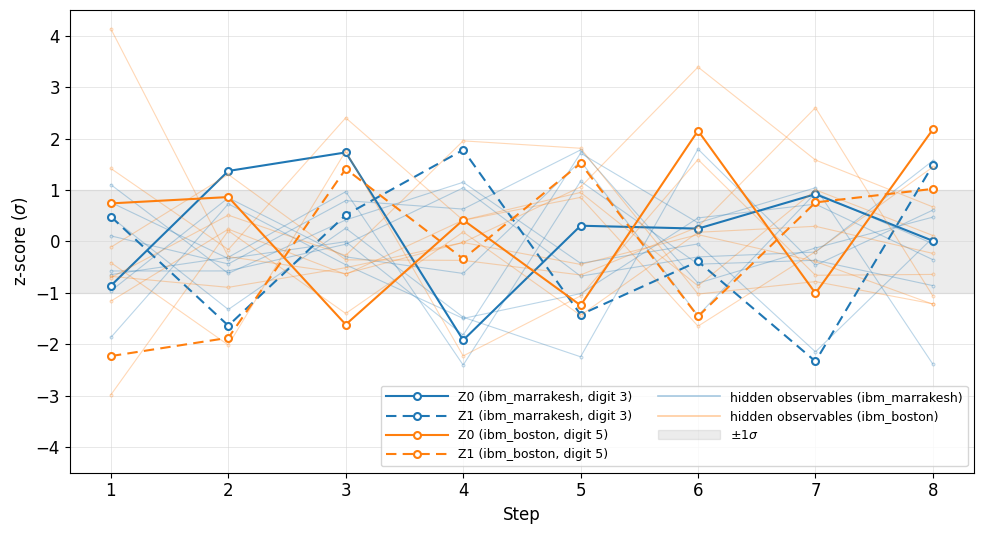

In [11]:
from matplotlib.lines import Line2D
plt.rcParams.update({'font.size': 12})


fig, ax = plt.subplots(figsize=(10, 5.5))

output_idx = [names.index('Z0'), names.index('Z1')]
hidden_idx = [i for i in range(len(names)) if i not in output_idx]

backend_color = {
    'ibm_marrakesh': 'tab:blue',
    'ibm_boston'   : 'tab:orange',
}
output_linestyle = {'Z0': '-', 'Z1': (0, (5, 3))}  # Z1 dashed with wider gaps

for backend, res in results.items():
    n_steps = res['n_steps']
    steps   = np.arange(1, n_steps+1)
    color   = backend_color[backend]

    for j in hidden_idx:
        ax.plot(steps, res['zscore'][:, j], color=color, alpha=0.3,
                 linewidth=0.8, marker='o', markersize=2,
                 markerfacecolor='white', markeredgewidth=0.8, markeredgecolor=color)

    for j in output_idx:
        name = names[j]
        ax.plot(steps, res['zscore'][:, j], color=color,
                 linestyle=output_linestyle[name], marker='o', markersize=5,
                 linewidth=1.5, markerfacecolor='white', markeredgewidth=1.5,
                 markeredgecolor=color,
                 label=f"{name} ({backend}, digit {res['digit']})")

ax.set_ylim(-4.5, 4.5)
ax.axhspan(-1, 1, color='gray', alpha=0.15, label=r'$\pm 1\sigma$')
# ax.axhline(0, color='black', linewidth=0.8)
ax.grid(True, color='lightgray', linewidth=0.6, alpha=0.6)
ax.set_xlabel('Step')
ax.set_ylabel('z-score ($\\sigma$)')
# ax.set_title('Fixed-hidden mode: QESEM vs Statevector z-score\n(Z0 solid, Z1 dashed; thin lines are hidden-state observables)')
ax.set_xticks(np.arange(1, 9))

# Build legend: output lines (from labeled plots) + hidden-line proxies + ±1σ band
handles, labels = ax.get_legend_handles_labels()
hidden_proxies = [
    Line2D([0], [0], color=backend_color[b], alpha=0.4, linewidth=1.2,
           label=f"hidden observables ({b})")
    for b in results.keys()
]
handles = handles[:-1] + hidden_proxies + handles[-1:]  # insert before ±1σ (last item)
labels  = labels[:-1] + [p.get_label() for p in hidden_proxies] + labels[-1:]

ax.legend(handles, labels, loc='lower right', fontsize=9, ncol=2, handlelength=5)
fig.tight_layout()
fig.savefig('figure8_overlay_zscore.png', dpi=200)
plt.show()

## Figure 9 (overlay) — L2 distance, both backends

Area-fill style matching the original Figure 9, with the same backend
colors used in Figure 8 (ibm_marrakesh: blue, ibm_boston: orange).

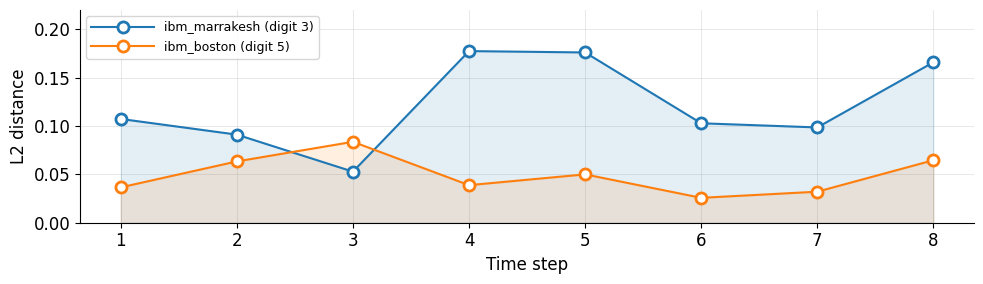

In [12]:
fig, ax = plt.subplots(figsize=(10, 3))

for backend, res in results.items():
    n_steps = res['n_steps']
    steps   = np.arange(1, n_steps+1)
    color   = backend_color[backend]

    ax.plot(steps, res['l2'], color=color, linewidth=1.5,
             marker='o', markersize=8, markerfacecolor='white',
             markeredgewidth=2, markeredgecolor=color,
             label=f"{backend} (digit {res['digit']})")
    ax.fill_between(steps, res['l2'], 0, color=color, alpha=0.12)

ax.set_ylim(0, 0.22)
ax.set_xlabel('Time step')
ax.set_ylabel('L2 distance')
# ax.set_title('Sequential mode: hidden-state L2 distance over 8 steps')
ax.set_xticks(np.arange(1, 9))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, color='lightgray', linewidth=0.6, alpha=0.6)
ax.set_axisbelow(True)
ax.legend(loc='upper left', fontsize=9, handlelength=5)
fig.tight_layout()
fig.savefig('figure9_overlay_l2distance.png', dpi=200)
plt.show()


## Summary table

In [8]:
print(f"{'Backend':<15} {'Digit':<7} {'QESEM pred':<14} {'SV pred':<12} {'Match?'}")
for backend, res in results.items():
    qesem_digit = LABEL_TO_DIGIT[res['qesem_pred']]
    sv_digit    = LABEL_TO_DIGIT[res['sv_pred']]
    match = "yes" if (qesem_digit == res['digit'] == sv_digit) else "no"
    print(f"{backend:<15} {res['digit']:<7} {qesem_digit:<14} {sv_digit:<12} {match}")


Backend         Digit   QESEM pred     SV pred      Match?
ibm_marrakesh   3       3              3            yes
ibm_boston      5       5              5            yes
